<a href="https://colab.research.google.com/github/Emanuel2234/Causas_muerte_chile_2023_2026/blob/main/Causas_de_Defunci%C3%B3n_chile_2023_03_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis mineria de datos : Causas de muerte en chile periodo 2023 a 03/2026

Se realiza analsis a casos de muerte en chile en base a un dataset del minsal que cubren el periodo 2023 a marzo del 2026, en el cual veremos las principales causas de muerte en nuestro pais y asi analizar es estilo de vida de los chilenos y chilenas otra cosa que podemos rescatar es la edad a la que muere la poblacion chilena.

Enlace de Fuente: https://deis.minsal.cl/#datosabiertos

**Estudiante: Emanuel Farias**

**Curso: MINERIA DE DATOS**

**Seccion: 004D**

**Profesor: Carlos Muñoz**


# Fase 1: entendimiento del negocio
El objetivo aquí es entender el fenómeno de la mortalidad desde una perspectiva social. Queremos saber de qué estamos muriendo realmente y si factores como el género, el lugar de la defunción o la edad tienen una relación directa que podamos modelar para mejorar la toma de decisiones en salud pública.

In [52]:
# ============================================================
# LIBRERÍAS
# ============================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División del dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelos de Machine Learning
from sklearn.linear_model import LinearRegression          # Regresión Lineal Múltiple
from sklearn.tree import DecisionTreeRegressor, export_text # Árbol de Decisión + extracción de reglas

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, r2_score  # MAE y R²

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Comprensión de los Datos
En esta parte cargamos el dataset del DEIS y revisamos qué tenemos. Nos encontramos con un volumen importante de información: 407,897 registros y 28 columnas iniciales.

In [53]:
#se importa el dataset
df = pd.read_csv('/content/DEFUNCIONES_FUENTE_DEIS_2023_2026_14042026.csv', encoding='latin-1', sep=';')

In [54]:
df.shape # se logra apreciar 407897 filas y 28 columnas

(407897, 27)

In [55]:
df.columns

Index(['AÑO', 'FECHA_DEF', 'SEXO_NOMBRE', 'EDAD_TIPO', 'EDAD_CANT',
       'COD_COMUNA', 'COMUNA', 'NOMBRE_REGION', 'DIAG1', 'CAPITULO_DIAG1',
       'GLOSA_CAPITULO_DIAG1', 'CODIGO_GRUPO_DIAG1', 'GLOSA_GRUPO_DIAG1',
       'CODIGO_CATEGORIA_DIAG1', 'GLOSA_CATEGORIA_DIAG1',
       'CODIGO_SUBCATEGORIA_DIAG1', 'GLOSA_SUBCATEGORIA_DIAG1', 'DIAG2',
       'CAPITULO_DIAG2', 'GLOSA_CAPITULO_DIAG2', 'CODIGO_GRUPO_DIAG2',
       'GLOSA_GRUPO_DIAG2', 'CODIGO_CATEGORIA_DIAG2', 'GLOSA_CATEGORIA_DIAG2',
       'CODIGO_SUBCATEGORIA_DIAG2', 'GLOSA_SUBCATEGORIA_DIAG2',
       'LUGAR_DEFUNCION'],
      dtype='object')

Aqui se puede ver las columnas que proveiene de este dataset de las cuales podemos decir:

AÑO: año de la defucion (variable númerica).

FECHA_DEF: fecha completa de la misma (variables categoricas).

EDAD_CANT: edad del fallecido (variable númerica).

SEXO: genero del fallecido/a(variables categoricas).

EDAD_TIPO: codigo que indica la unidad de medida (variables categoricas).

NOMBRE_REGION, COMUNA y COD_COMUNA: idicacion de donde ocurrio (variables categoricas).

LUGAR_DEFUNCION: indica si ocurrio en casa, hospital o via publica (variables categoricas).

DIAG1: corresponde al codigo alfanumerico de la enfermedad o condicion (variables categoricas).

GLOSA_CAPITULO_DIAG1:este seria el apartado donde dice que enfermedad es segun el codigo (variables categoricas).

CAPITULO_DIAG1: numero de los capitulos medicos (variables categoricas).

CODIGO_CATEGORIA_DIAG1: codigo jerarquico del diagnostico (variables categoricas).

DIAG2 y sus derivados: trata de los mismo que el diag1 pero solo que es en base a causas externas del fallecimiento, para todas sus dereivadas y la misma es (variables categoricas)

EDAD: variable limpia de la edad cronologica en años (variable númerica).

Causa_Principal: variable target, es la clasificacion agrupada de la causa de muerte (variables categoricas).



In [56]:
df.head()

,AÑO,FECHA_DEF,SEXO_NOMBRE,EDAD_TIPO,EDAD_CANT,COD_COMUNA,COMUNA,NOMBRE_REGION,DIAG1,CAPITULO_DIAG1,...,DIAG2,CAPITULO_DIAG2,GLOSA_CAPITULO_DIAG2,CODIGO_GRUPO_DIAG2,GLOSA_GRUPO_DIAG2,CODIGO_CATEGORIA_DIAG2,GLOSA_CATEGORIA_DIAG2,CODIGO_SUBCATEGORIA_DIAG2,GLOSA_SUBCATEGORIA_DIAG2,LUGAR_DEFUNCION
0,2026,23-03-2026,Hombre,1,64,13129.0,San Joaquín,Metropolitana de Santiago,I10X,I00-I99,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
1,2026,07-03-2026,Hombre,1,71,14107.0,Paillaco,De Los Ríos,C61X,C00-D48,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
2,2026,09-03-2026,Mujer,1,72,8112.0,Hualpén,Del Bíobío,J841,J00-J99,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
3,2026,18-01-2026,Hombre,1,70,5801.0,Quilpué,De Valparaíso,C719,C00-D48,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
4,2026,08-03-2026,Mujer,1,75,13114.0,Las Condes,Metropolitana de Santiago,C56X,C00-D48,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación


le hechamos un pequeño vistazo al contenido del dataset para familiarizarnos con los datos

In [57]:
# Aseguramos que la Edad sea numérica y renombramos el Sexo
df['EDAD'] = pd.to_numeric(df['EDAD_CANT'], errors='coerce')
df.rename(columns={'SEXO_NOMBRE': 'SEXO'}, inplace=True)

In [58]:
# convertimos a formato fecha por si acaso
df['FECHA_DEF'] = pd.to_datetime(df['FECHA_DEF'])

# extraemos el número del mes
df['MES'] = df['FECHA_DEF'].dt.month

meses_es = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
df['MES_NOMBRE'] = df['MES'].map(meses_es)


print(df[['FECHA_DEF', 'MES', 'MES_NOMBRE']].head())

   FECHA_DEF  MES MES_NOMBRE
0 2026-03-23    3      Marzo
1 2026-03-07    3      Marzo
2 2026-03-09    3      Marzo
3 2026-01-18    1      Enero
4 2026-03-08    3      Marzo


In [59]:
# lista de columnas a eliminar
columnas_a_eliminar = ['EDAD_TIPO', 'COD_COMUNA', 'FECHA_DEF']

# eliminación de las columnas
# axis=1 indica que estamos eliminando columnas, no filas
# inplace=True aplica los cambios directamente al DataFrame original
df.drop(columns=columnas_a_eliminar, axis=1, inplace=True, errors='ignore')

# verificamos cómo quedó el DataFrame
print("Columnas restantes después de la limpieza:")
print(df.columns.tolist())

# mostramos las primeras filas para confirmar
df.head()

Columnas restantes después de la limpieza:
['AÑO', 'SEXO', 'EDAD_CANT', 'COMUNA', 'NOMBRE_REGION', 'DIAG1', 'CAPITULO_DIAG1', 'GLOSA_CAPITULO_DIAG1', 'CODIGO_GRUPO_DIAG1', 'GLOSA_GRUPO_DIAG1', 'CODIGO_CATEGORIA_DIAG1', 'GLOSA_CATEGORIA_DIAG1', 'CODIGO_SUBCATEGORIA_DIAG1', 'GLOSA_SUBCATEGORIA_DIAG1', 'DIAG2', 'CAPITULO_DIAG2', 'GLOSA_CAPITULO_DIAG2', 'CODIGO_GRUPO_DIAG2', 'GLOSA_GRUPO_DIAG2', 'CODIGO_CATEGORIA_DIAG2', 'GLOSA_CATEGORIA_DIAG2', 'CODIGO_SUBCATEGORIA_DIAG2', 'GLOSA_SUBCATEGORIA_DIAG2', 'LUGAR_DEFUNCION', 'EDAD', 'MES', 'MES_NOMBRE']


,AÑO,SEXO,EDAD_CANT,COMUNA,NOMBRE_REGION,DIAG1,CAPITULO_DIAG1,GLOSA_CAPITULO_DIAG1,CODIGO_GRUPO_DIAG1,GLOSA_GRUPO_DIAG1,...,CODIGO_GRUPO_DIAG2,GLOSA_GRUPO_DIAG2,CODIGO_CATEGORIA_DIAG2,GLOSA_CATEGORIA_DIAG2,CODIGO_SUBCATEGORIA_DIAG2,GLOSA_SUBCATEGORIA_DIAG2,LUGAR_DEFUNCION,EDAD,MES,MES_NOMBRE
0,2026,Hombre,64,San Joaquín,Metropolitana de Santiago,I10X,I00-I99,Enfermedades del sistema circulatorio,I10-I15,Enfermedades hipertensivas,...,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica,64,3,Marzo
1,2026,Hombre,71,Paillaco,De Los Ríos,C61X,C00-D48,Tumores [Neoplasias],C60-C63,Tumores malignos de los órganos genitales masc...,...,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,71,3,Marzo
2,2026,Mujer,72,Hualpén,Del Bíobío,J841,J00-J99,Enfermedades del sistema respiratorio,J80-J84,Otras enfermedades respiratorias que afectan p...,...,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica,72,3,Marzo
3,2026,Hombre,70,Quilpué,De Valparaíso,C719,C00-D48,Tumores [Neoplasias],C69-C72,"Tumores malignos del ojo, del encéfalo y de ot...",...,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,70,1,Enero
4,2026,Mujer,75,Las Condes,Metropolitana de Santiago,C56X,C00-D48,Tumores [Neoplasias],C51-C58,Tumores malignos de los órganos genitales feme...,...,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,75,3,Marzo


In [60]:
df.isna().sum()

,0
AÑO,0
SEXO,0
EDAD_CANT,0
COMUNA,63
NOMBRE_REGION,63
DIAG1,0
CAPITULO_DIAG1,4
GLOSA_CAPITULO_DIAG1,4
CODIGO_GRUPO_DIAG1,4
GLOSA_GRUPO_DIAG1,4


# Se logra percibir que todas estas variables poseen nulos

COD_COMUNA

COMUNA

NOMBRE_REGION

GLOSA_CAPITULO_DIAG1

CODIGO_GRUPO_DIAG1

GLOSA_CATEGORIA_DIAG1

CODIGO_SUBCATEGORIA_DIAG1

GLOSA_SUBCATEGORIA_DIAG1

DIAG2

CAPITULO_DIAG2

GLOSA_CAPITULO_DIAG2

CODIGO_GRUPO_DIAG2

GLOSA_GRUPO_DIAG2

CODIGO_CATEGORIA_DIAG2

GLOSA_CATEGORIA_DIAG2

CODIGO_SUBCATEGORIA_DIAG2

GLOSA_SUBCATEGORIA_DIAG2



una de las posibles causas de que haya tantos nulos en los DIAG2 es que puede haber muerto de causas naturales por lo que esa seccion no era necesario llenarla.

la los de comuna y nombre_region podria deberse a las personas en situacion de calle, tambien si fueron extrajeros o transeuntes que su residencia no esta en chile tal cual.



In [61]:
df.describe().round() # se le aplica estadistica a columnas numericas

,AÑO,EDAD_CANT,EDAD,MES
count,407897.0,407897.0,407897.0,407897.0
mean,2024.0,73.0,73.0,6.0
std,1.0,18.0,18.0,3.0
min,2023.0,0.0,0.0,1.0
25%,2023.0,65.0,65.0,3.0
50%,2024.0,77.0,77.0,6.0
75%,2025.0,86.0,86.0,9.0
max,2026.0,140.0,140.0,12.0


al comienzo se logra ver la cantidad de registros que seria 407897, luego se muestra la media el año 2024, con tipo de edad 1, 73 años de fallecido (seria el promedio), su respectivo codigo de comuna y otra vez su edad.

## 3. Preparación de los Datos
Quitamos lo que no sirve e imputamos los nulos para no perder registros valiosos.


In [62]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407897 entries, 0 to 407896
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   AÑO                        407897 non-null  int64 
 1   SEXO                       407897 non-null  object
 2   EDAD_CANT                  407897 non-null  int64 
 3   COMUNA                     407834 non-null  object
 4   NOMBRE_REGION              407834 non-null  object
 5   DIAG1                      407897 non-null  object
 6   CAPITULO_DIAG1             407893 non-null  object
 7   GLOSA_CAPITULO_DIAG1       407893 non-null  object
 8   CODIGO_GRUPO_DIAG1         407893 non-null  object
 9   GLOSA_GRUPO_DIAG1          407893 non-null  object
 10  CODIGO_CATEGORIA_DIAG1     407893 non-null  object
 11  GLOSA_CATEGORIA_DIAG1      407893 non-null  object
 12  CODIGO_SUBCATEGORIA_DIAG1  407893 non-null  object
 13  GLOSA_SUBCATEGORIA_DIAG1   407893 non-null  

In [63]:
# Ver si hay nulos
df.isnull().any().any()

np.True_

si se encontraron nulos por lo que debemos tratarlos

In [64]:
# Conteo de nulos por columna
for col in df.columns:
    print(col, df[col].isna().sum())

AÑO 0
SEXO 0
EDAD_CANT 0
COMUNA 63
NOMBRE_REGION 63
DIAG1 0
CAPITULO_DIAG1 4
GLOSA_CAPITULO_DIAG1 4
CODIGO_GRUPO_DIAG1 4
GLOSA_GRUPO_DIAG1 4
CODIGO_CATEGORIA_DIAG1 4
GLOSA_CATEGORIA_DIAG1 4
CODIGO_SUBCATEGORIA_DIAG1 4
GLOSA_SUBCATEGORIA_DIAG1 4
DIAG2 284001
CAPITULO_DIAG2 381588
GLOSA_CAPITULO_DIAG2 381588
CODIGO_GRUPO_DIAG2 381588
GLOSA_GRUPO_DIAG2 381588
CODIGO_CATEGORIA_DIAG2 381588
GLOSA_CATEGORIA_DIAG2 381588
CODIGO_SUBCATEGORIA_DIAG2 381588
GLOSA_SUBCATEGORIA_DIAG2 381588
LUGAR_DEFUNCION 0
EDAD 0
MES 0
MES_NOMBRE 0


se realiza el conteo de nulos

In [65]:
#limpieza y tratamiento

# separar variables categóricas y numéricas
ctext = df.select_dtypes(include=['object']).columns
cnum = df.select_dtypes(exclude=['object']).columns

# imputacion por la media a variables cuantitativas
for columna in cnum:
    mean = df[columna].mean()

    df[columna] = df[columna].fillna(mean)

# imputacion por la moda a variables categóricas
for columna in ctext:
    mode = df[columna].mode()[0]
    df[columna] = df[columna].fillna(mode)


In [66]:
# Ver si hay nulos
df.isnull().any().any()

np.False_

En este punto los nulos fueron imputados

## 4. Análisis Exploratorio
En esta parte nos dedicamos a explorar los datos para entender qué nos están diciendo antes de aplicar cualquier modelo. La idea es responder preguntas simples pero importantes: ***¿de qué se muere la gente en Chile?, ¿a qué edad?, ¿esto ha cambiado con los años?*** Para responder estas preguntas usamos gráficos que nos permiten ver los patrones más importantes del dataset de forma clara y directa.

In [67]:
# CREACIÓN DE VARIABLE OBJETIVO (Clasificación CIE-10 Completa)
def clasificar_todas_las_causas(fila):
    # 1. Primero aislamos las Causas Externas usando DIAG2 (Regla DEIS)
    diag2 = str(fila['DIAG2']).strip().upper()
    if diag2.startswith(('V', 'W', 'X', 'Y')):
        return 'Causas Externas (Accidentes/Violencia)'

    # 2. Agrupamos TODAS las enfermedades principales usando DIAG1
    diag1 = str(fila['DIAG1']).strip().upper()

    if diag1.startswith(('A', 'B')):
        return 'Infecciosas y Parasitarias (ej. COVID, VIH)'
    elif diag1.startswith(('C', 'D')):
        return 'Neoplasias (Cáncer y Tumores)'
    elif diag1.startswith('E'):
        return 'Endocrinas y Nutricionales (ej. Diabetes)'
    elif diag1.startswith('F'):
        return 'Trastornos Mentales y del Comportamiento'
    elif diag1.startswith('G'):
        return 'Enfermedades del Sistema Nervioso'
    elif diag1.startswith('H'):
        return 'Enfermedades del Ojo y Oído'
    elif diag1.startswith('I'):
        return 'Enfermedades del Sistema Circulatorio'
    elif diag1.startswith('J'):
        return 'Enfermedades del Sistema Respiratorio'
    elif diag1.startswith('K'):
        return 'Enfermedades del Sistema Digestivo'
    elif diag1.startswith('L'):
        return 'Enfermedades de la Piel'
    elif diag1.startswith('M'):
        return 'Enfermedades del Sistema Osteomuscular'
    elif diag1.startswith('N'):
        return 'Enfermedades del Sistema Genitourinario'
    elif diag1.startswith('O'):
        return 'Embarazo, Parto y Puerperio'
    elif diag1.startswith('P'):
        return 'Afecciones Perinatales'
    elif diag1.startswith('Q'):
        return 'Malformaciones Congénitas'
    elif diag1.startswith('R'):
        return 'Causas Mal Definidas / Síntomas'
    else:
        return 'Otras Causas / No Especificado'

# Aplicamos la nueva función
df['Causa_Principal'] = df.apply(clasificar_todas_las_causas, axis=1)

print("Distribución Detallada de las Clases (Variable Objetivo):\n")
print(df['Causa_Principal'].value_counts(normalize=True) * 100)

Distribución Detallada de las Clases (Variable Objetivo):

Causa_Principal
Neoplasias (Cáncer y Tumores)                  25.616516
Enfermedades del Sistema Circulatorio          25.094816
Enfermedades del Sistema Respiratorio          11.932424
Enfermedades del Sistema Digestivo              7.188579
Causas Externas (Accidentes/Violencia)          6.449422
Enfermedades del Sistema Nervioso               5.158900
Endocrinas y Nutricionales (ej. Diabetes)       4.174338
Causas Mal Definidas / Síntomas                 3.027970
Enfermedades del Sistema Genitourinario         2.851700
Trastornos Mentales y del Comportamiento        2.807572
Infecciosas y Parasitarias (ej. COVID, VIH)     2.236349
Otras Causas / No Especificado                  1.020846
Enfermedades de la Piel                         0.863208
Enfermedades del Sistema Osteomuscular          0.644035
Malformaciones Congénitas                       0.490810
Afecciones Perinatales                          0.400591
Embarazo, Par

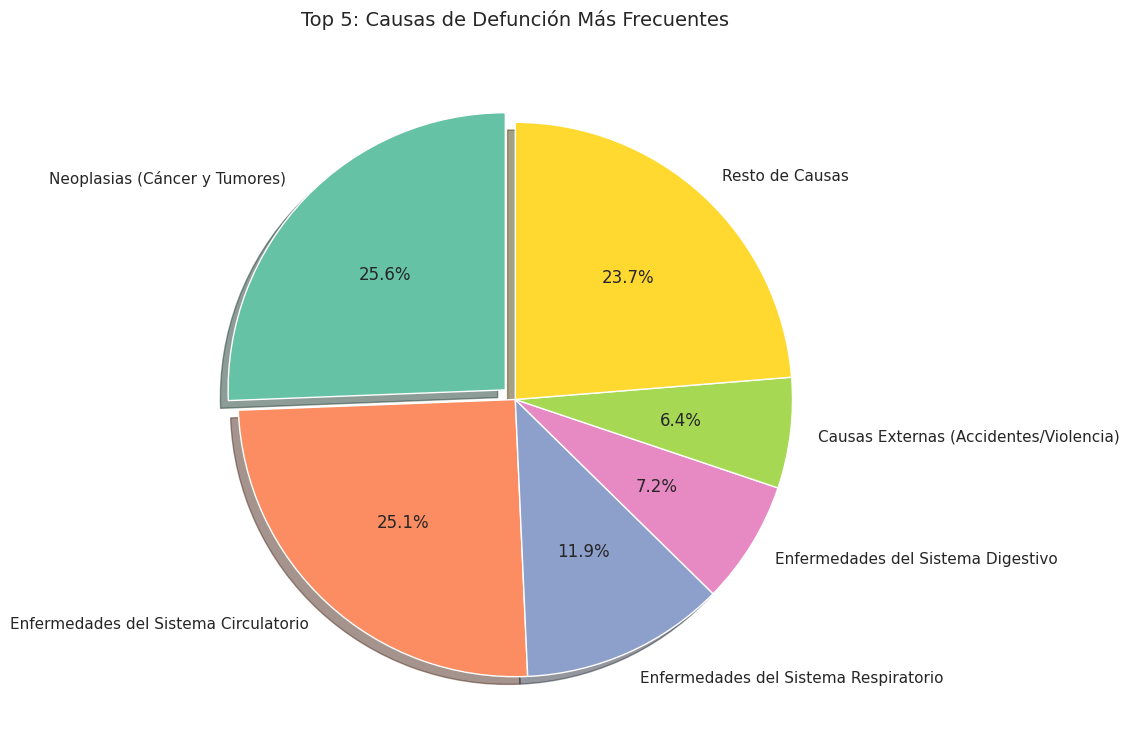

In [68]:
# Gráfico de Torta de la Variable Objetivo
plt.figure(figsize=(9, 9))

# Obtenemos todas las frecuencias
frecuencias_completas = df['Causa_Principal'].value_counts()

# Se separa el top 5 del resto de enfermedades
top_5 = frecuencias_completas.nlargest(5)
resto_sumado = pd.Series([frecuencias_completas.iloc[5:].sum()], index=['Resto de Causas'])

# Unimos el Top 5 con la nueva categoría "Resto de Causas"
frecuencias_final = pd.concat([top_5, resto_sumado])

# Destacamos levemente la causa principal (posición 0)
explode = [0.05 if i == 0 else 0 for i in range(len(frecuencias_final))]

# Generamos la paleta de colores (6 colores: 5 del top + 1 del resto)
colores = sns.color_palette('Set2', len(frecuencias_final))

# Generamos el gráfico de torta
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Top 5: Causas de Defunción Más Frecuentes', fontsize=14, pad=20)
plt.show()

en esta seccion quise clasificar las enfermedades por sus codigo para tener mas claro de que muere la gente en chile en este perido de tiempo, lo quye se logra apreciar que las 5 causas de muerte principales son:

Neoplasias (Cáncer y Tumores) con 25%.

Enfermedades del Sistema Circulatorio          25%.

Enfermedades del Sistema Respiratorio          11%.

Enfermedades del Sistema Digestivo              7%.

Causas Externas (Accidentes/Violencia)          6%.

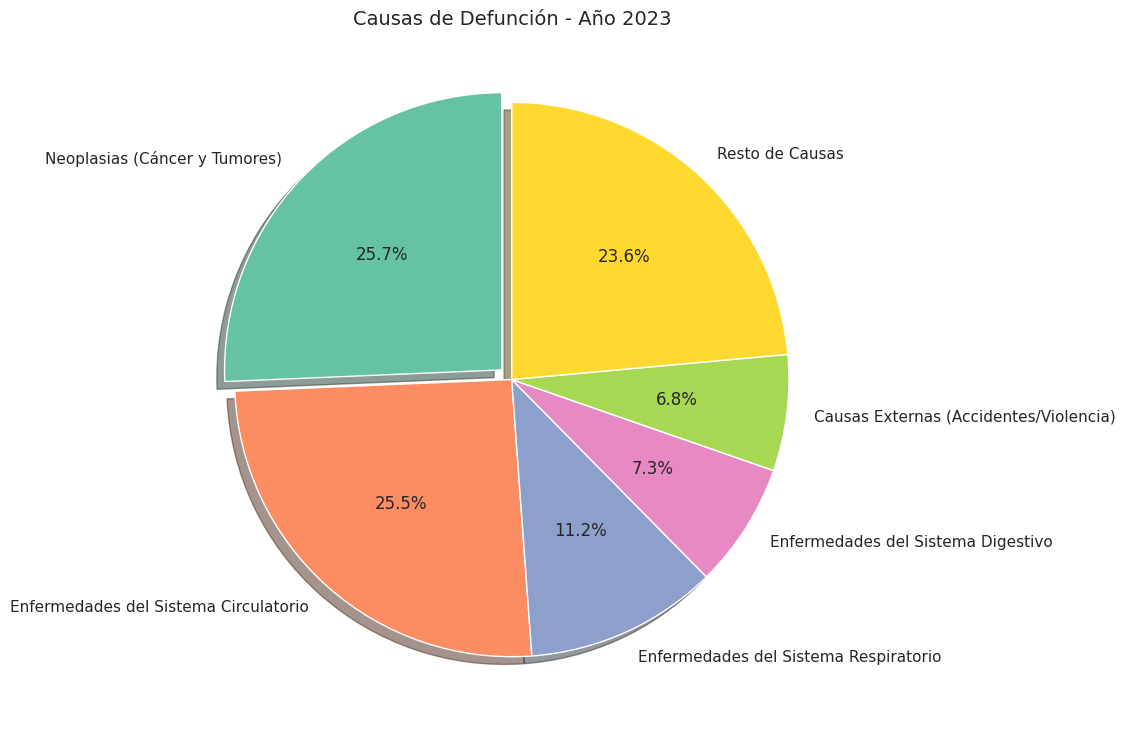

In [69]:
df_2023 = df[df['AÑO'] == 2023]

frecuencias = df_2023['Causa_Principal'].value_counts()
top_5 = frecuencias.nlargest(5)
resto = pd.Series([frecuencias.iloc[5:].sum()], index=['Resto de Causas'])
frecuencias_final = pd.concat([top_5, resto])

explode = [0.05 if j == 0 else 0 for j in range(len(frecuencias_final))]
colores = sns.color_palette('Set2', len(frecuencias_final))

plt.figure(figsize=(9, 9))
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Causas de Defunción - Año 2023', fontsize=14)
plt.show()

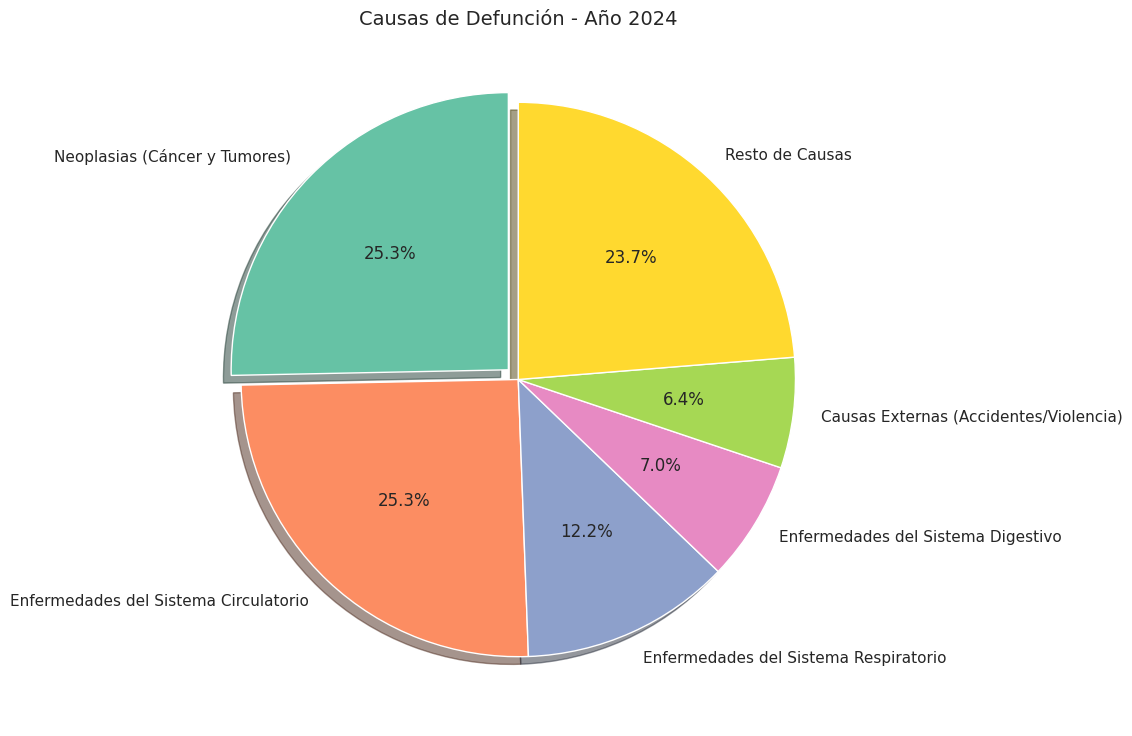

In [70]:
df_2024 = df[df['AÑO'] == 2024]

frecuencias = df_2024['Causa_Principal'].value_counts()
top_5 = frecuencias.nlargest(5)
resto = pd.Series([frecuencias.iloc[5:].sum()], index=['Resto de Causas'])
frecuencias_final = pd.concat([top_5, resto])

explode = [0.05 if j == 0 else 0 for j in range(len(frecuencias_final))]
colores = sns.color_palette('Set2', len(frecuencias_final))

plt.figure(figsize=(9, 9))
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Causas de Defunción - Año 2024', fontsize=14)
plt.show()

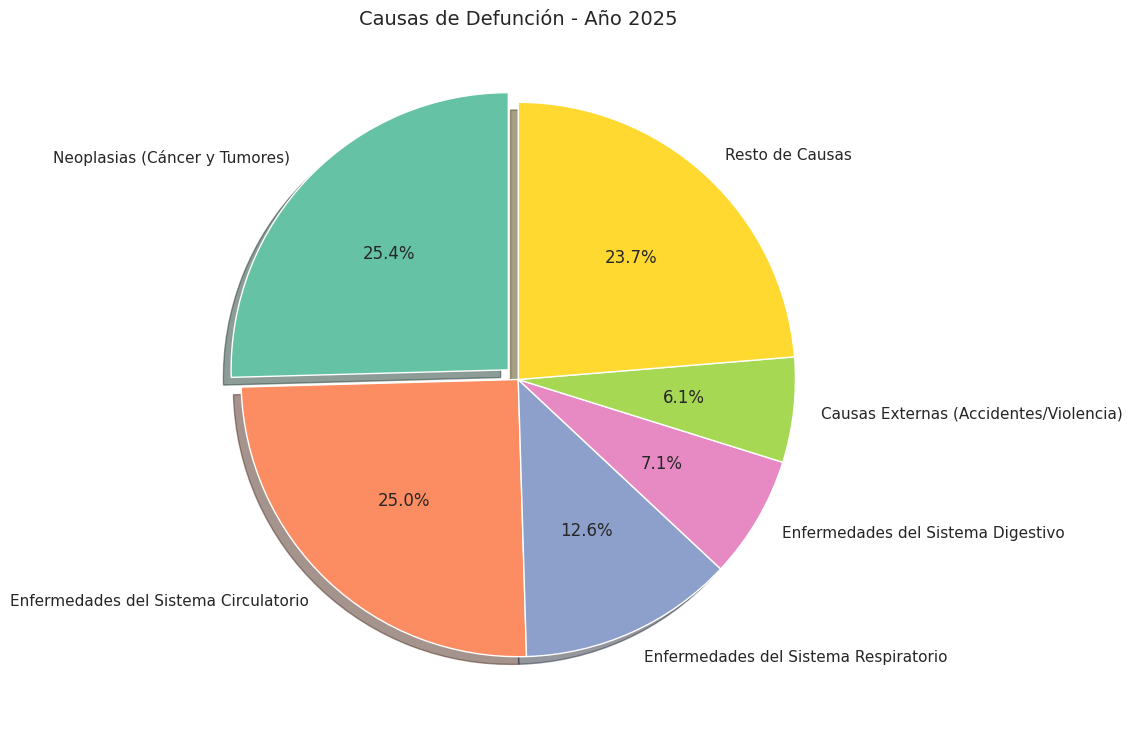

In [71]:
df_2025 = df[df['AÑO'] == 2025]

frecuencias = df_2025['Causa_Principal'].value_counts()
top_5 = frecuencias.nlargest(5)
resto = pd.Series([frecuencias.iloc[5:].sum()], index=['Resto de Causas'])
frecuencias_final = pd.concat([top_5, resto])

explode = [0.05 if j == 0 else 0 for j in range(len(frecuencias_final))]
colores = sns.color_palette('Set2', len(frecuencias_final))

plt.figure(figsize=(9, 9))
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Causas de Defunción - Año 2025', fontsize=14)
plt.show()

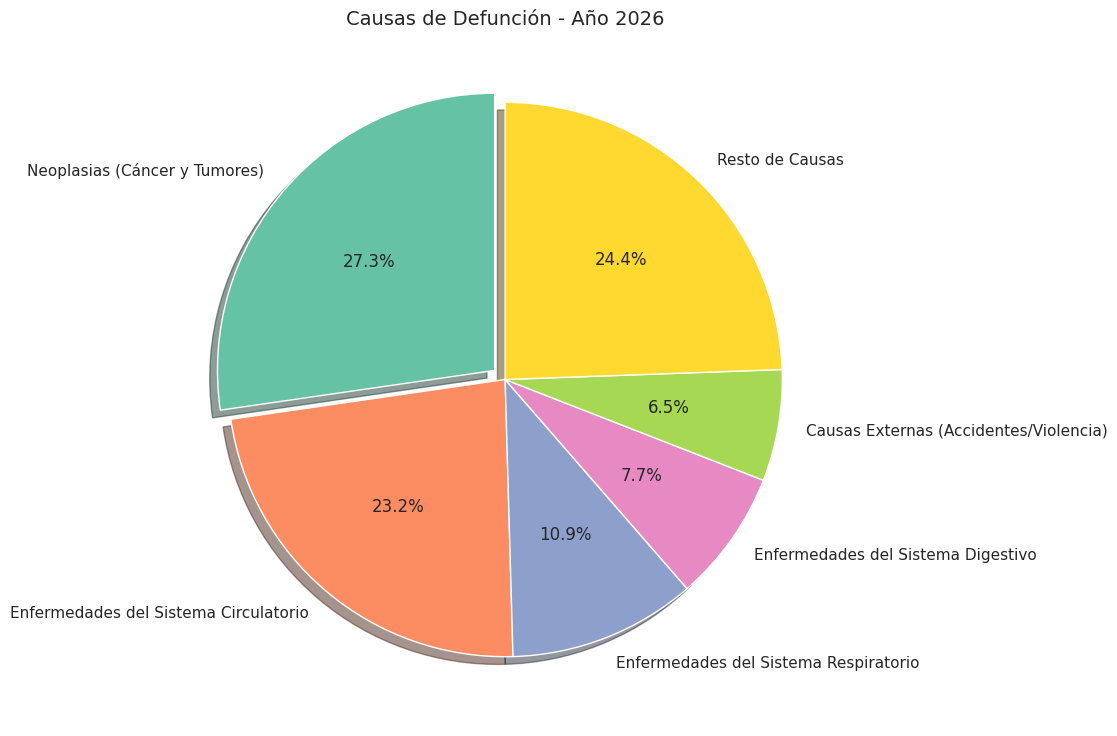

In [72]:
df_2026 = df[df['AÑO'] == 2026]

frecuencias = df_2026['Causa_Principal'].value_counts()
top_5 = frecuencias.nlargest(5)
resto = pd.Series([frecuencias.iloc[5:].sum()], index=['Resto de Causas'])
frecuencias_final = pd.concat([top_5, resto])

explode = [0.05 if j == 0 else 0 for j in range(len(frecuencias_final))]
colores = sns.color_palette('Set2', len(frecuencias_final))

plt.figure(figsize=(9, 9))
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Causas de Defunción - Año 2026', fontsize=14)
plt.show()

| Causa | 2023 | 2024 | 2025 | Tendencia |
|---|---|---|---|---|
| Neoplasias (Cáncer y Tumores) | 25.7% | 25.3% | 25.4% | Estable, lidera |
| Enf. del Sistema Circulatorio | 25.5% | 25.3% | 25.0% | Bajando levemente |
| Enf. del Sistema Respiratorio | 11.2% | 12.2% | 12.6% | Subiendo |
| Enf. del Sistema Digestivo | 7.3% | 7.0% | 7.1% | Estable |
| Causas Externas (Acc./Violencia) | 6.8% | 6.4% | 6.1% | Bajando |
| Resto de Causas | 23.6% | 23.7% | 23.7% | Estable |

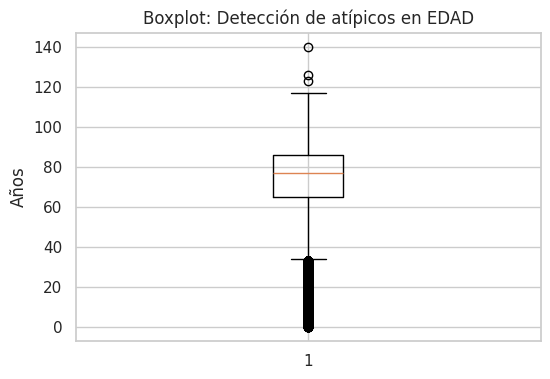

In [73]:
# Boxplot para detectar atípicos en la edad
plt.figure(figsize=(6, 4))

# Usamos dropna() por si quedó algún nulo residual
plt.boxplot(list(df['EDAD'].dropna()))
plt.title('Boxplot: Detección de atípicos en EDAD')
plt.ylabel('Años')
plt.show()

En el boxplot se puede apreciar que los valores dentro de la caja corresponden a la mediana que sabemos que son 77 años, en el borde inferior se encontrarian los 65 años que corresponde al percentil 25, en el borde superior corresponderia a los 86 años, esto nos demuestra que la gente en chile fallece en este rango de edad.

Con respecto la cola inferior de este boxplot se logra apreciar valores atipicos, pero estos podrian representar la mortalidad prematura.

Con respecto a los puntos superiores, puede significar personas que fallecieron con una edad altisima o puede ser que un error en los datos por lo que se vera mas adelante

In [74]:
# Verificación de tipos de datos
print(df[['EDAD', 'SEXO', 'LUGAR_DEFUNCION', 'Causa_Principal']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407897 entries, 0 to 407896
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   EDAD             407897 non-null  int64 
 1   SEXO             407897 non-null  object
 2   LUGAR_DEFUNCION  407897 non-null  object
 3   Causa_Principal  407897 non-null  object
dtypes: int64(1), object(3)
memory usage: 12.4+ MB
None


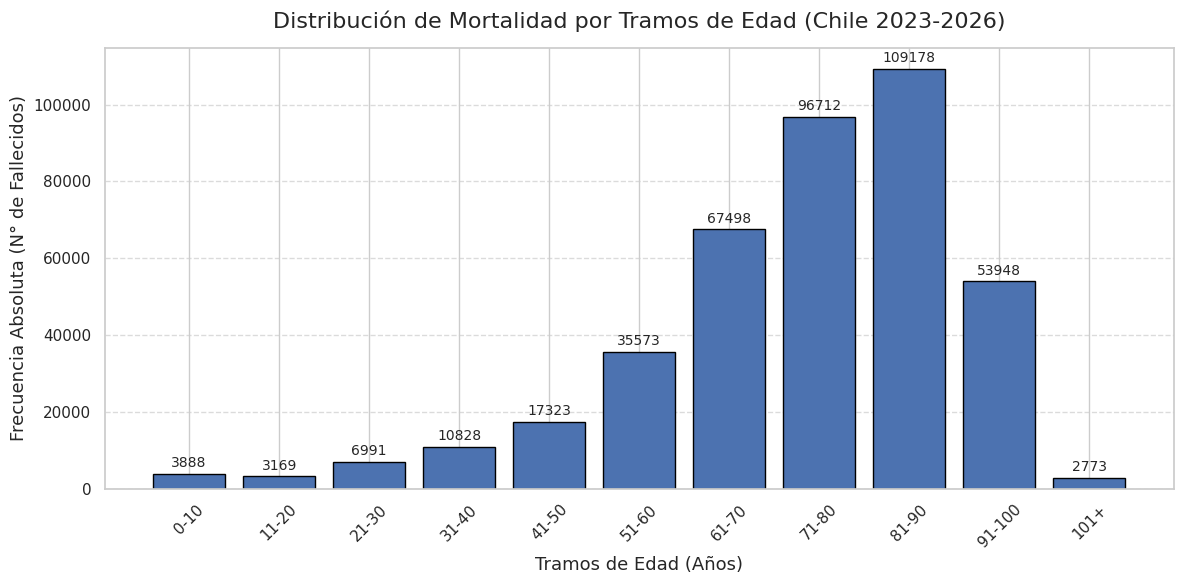

In [75]:
# Definimos los límites de los tramos
# Vamos de 0 a 120 años, saltando de 10 en 10
bins_edad = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120]
etiquetas_edad = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', '101+']

# Creamos una nueva columna con el tramo correspondiente para cada persona
df['Tramo_Edad'] = pd.cut(df['EDAD'], bins=bins_edad, labels=etiquetas_edad, right=True)

# Calculamos la frecuencia de muertes por tramo y ordenamos por el índice (de menor a mayor edad)
frecuencia_tramos = df['Tramo_Edad'].value_counts().sort_index()

# Generamos el Gráfico de Barras
plt.figure(figsize=(12, 6))
# Usamos un color profesional y bordes negros para que las barras destaquen
barras = plt.bar(frecuencia_tramos.index, frecuencia_tramos.values, color='#4C72B0', edgecolor='black')

# Agregamos los números arriba de cada barra para mayor precisión
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1000, int(yval), ha='center', va='bottom', fontsize=10)

plt.title('Distribución de Mortalidad por Tramos de Edad (Chile 2023-2026)', fontsize=16, pad=15)
plt.xlabel('Tramos de Edad (Años)', fontsize=13)
plt.ylabel('Frecuencia Absoluta (N° de Fallecidos)', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustamos el layout para que no se corten los textos
plt.tight_layout()
plt.show()

¿Que podemos rescatar de este grafico?, la mayoria de la poblacion adulta mayor suele morir en este tramo de 81 a 90 años acumulando 109.178 fallecidos seguido del tramo 71 a 80 que serian 96.712 casos

Podemos obserbar en el tramo a partir de los 50 años la mortalidad se dispara, se ven que entre los 41 a 50 y los 51 a 60 se duplica e incluso inprementa un poco mas de la mitad, la cual va incrementando hasta los 80.

Tambien se obserba que las muertes de jovenes son marginales a comparacion de volumen total, destacando el punto con menor mortalidad el tramo entre los 11 a 20 años con 3.169 casos.

ademas las muertes en los ultimos tramos es baja debido a que poca gente suele llegar a esa edad.



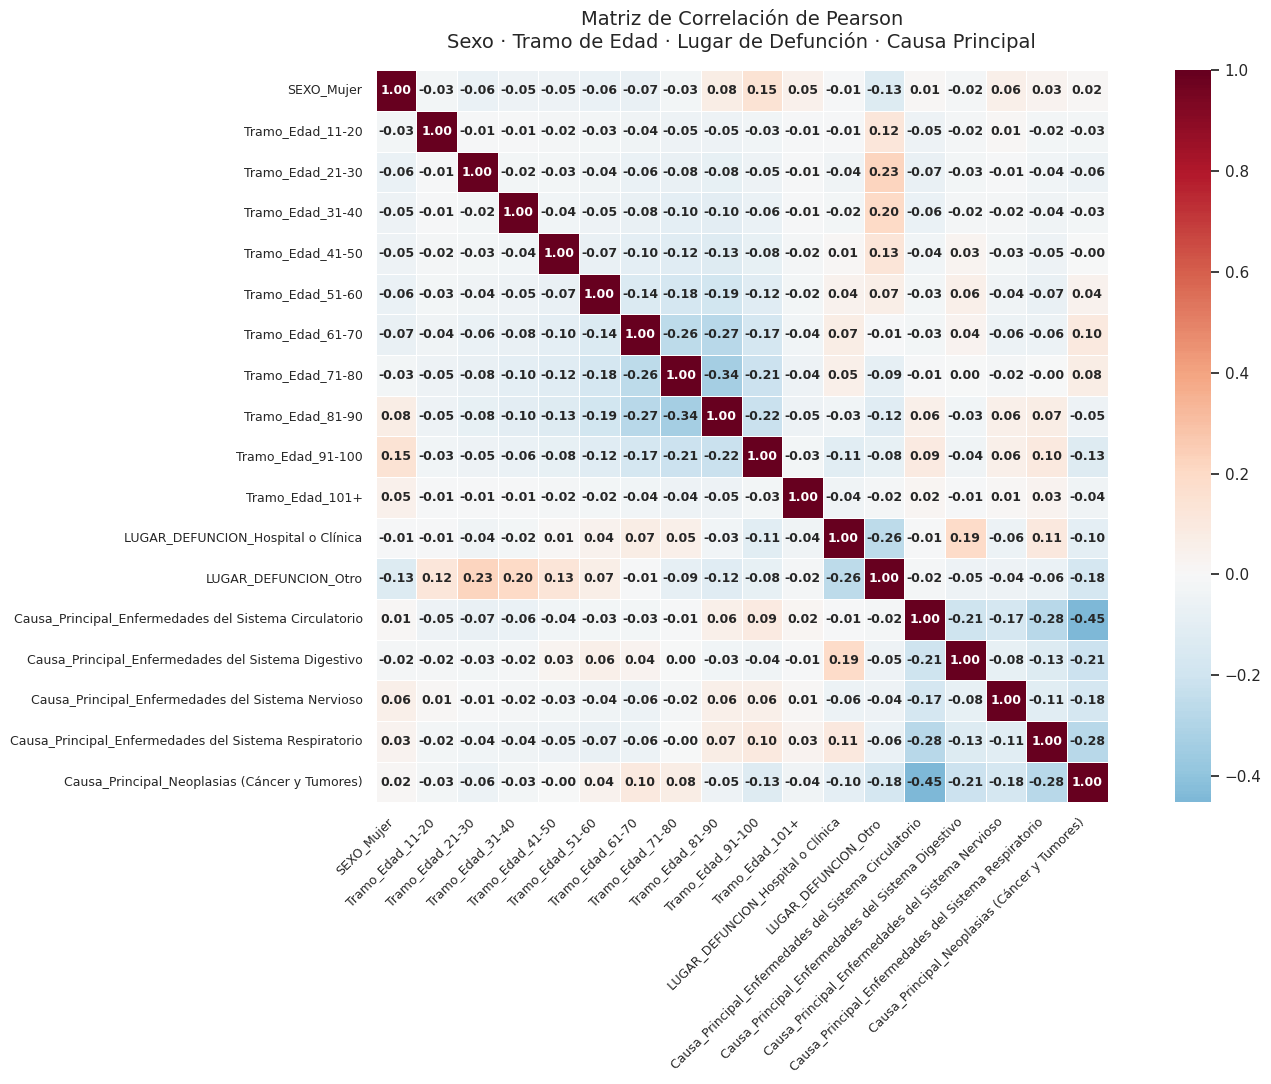

In [76]:

#PREPARACIÓN DE VARIABLES

#Tramos de edad
if 'Tramo_Edad' not in df.columns:
    bins_edad = [0, 15, 30, 45, 60, 75, 90, 120]
    etiquetas_edad = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90', '91+']
    df['Tramo_Edad'] = pd.cut(df['EDAD'], bins=bins_edad, labels=etiquetas_edad, right=True)


if 'Causa_Principal' not in df.columns:
    def clasificar_causas(fila):
        diag2 = str(fila.get('DIAG2', '')).strip().upper()
        if diag2.startswith(('V', 'W', 'X', 'Y')):
            return 'Causas Externas'
        diag1 = str(fila.get('DIAG1', '')).strip().upper()
        if diag1.startswith(('C', 'D')):   return 'Neoplasias'
        if diag1.startswith('I'):           return 'Circulatorio'
        if diag1.startswith('J'):           return 'Respiratorio'
        if diag1.startswith('K'):           return 'Digestivo'
        if diag1.startswith(('A', 'B')):    return 'Infecciosas'
        return 'Otras'
    df['Causa_Principal'] = df.apply(clasificar_causas, axis=1)


top_causas = df['Causa_Principal'].value_counts().nlargest(6).index.tolist()
df_final = df[df['Causa_Principal'].isin(top_causas)].copy()

columnas_modelo = [
    'SEXO',
    'Tramo_Edad',
    'LUGAR_DEFUNCION',
    'Causa_Principal'
]

#one-hot encoding
df_encoded = pd.get_dummies(df_final[columnas_modelo], drop_first=True, dtype=int)


#MATRIZ DE CORRELACIÓN DE PEARSON

corr_matrix = df_encoded.corr()

plt.figure(figsize=(16, 11))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.6,
    linecolor='white',
    annot_kws={"size": 9, "weight": "bold"},
    square=True
)

plt.title(
    "Matriz de Correlación de Pearson\nSexo · Tramo de Edad · Lugar de Defunción · Causa Principal",
    fontsize=14,
    pad=16
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()



La matriz confirma tres hallazgos clave: el cáncer se asocia a la franja 61-70 años mientras que las enfermedades circulatorias y respiratorias se extienden hasta los 81-90, morir fuera de un hospital es el predictor más fuerte de muerte joven con correlaciones de hasta +0.23 en los tramos 21-30 y 31-40, y las mujeres dominan los tramos de edad más avanzados lo que es consistente con su mayor esperanza de vida.


### 5. Modelado
Con los datos listos y habiendo entendido su comportamiento, llega el momento de construir los modelos. En esta etapa aplicamos dos algoritmos distintos: una Regresión Lineal para medir el impacto directo de cada variable sobre la edad de fallecimiento, y un Árbol de Decisión para identificar perfiles específicos de mortalidad de forma visual e interpretable.

In [78]:

columnas_x = ['SEXO', 'LUGAR_DEFUNCION', 'Causa_Principal']#predictorias
X_lr = pd.get_dummies(df_final[columnas_x], drop_first=True, dtype=int)
y_lr = df_final['EDAD']#objetivo a predecir


# 80 para entrenar
# 20 prueba

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

modelo_lr = LinearRegression()# Creamos el modelo de Regresión Lineal Múltiple


modelo_lr.fit(X_train_lr, y_train_lr)

y_pred_lr = modelo_lr.predict(X_test_lr)


print("Modelo entrenado correctamente ✓")
print(f"Registros de entrenamiento: {len(X_train_lr):,}")
print(f"Registros de prueba:        {len(X_test_lr):,}")

Modelo entrenado correctamente ✓
Registros de entrenamiento: 216,456
Registros de prueba:        54,115


El modelo se entrenó con 265.755 registros y se probará con 66.439, lo que en total suma 332.194 casos, que corresponde al dataset filtrado con las 6 causas principales

In [79]:

if 'Causa_Principal' not in df.columns:
    def clasificar_causas(fila):
        diag2 = str(fila.get('DIAG2', '')).strip().upper()
        if diag2.startswith(('V', 'W', 'X', 'Y')):
            return 'Causas Externas'
        diag1 = str(fila.get('DIAG1', '')).strip().upper()
        if diag1.startswith(('C', 'D')):  return 'Neoplasias'
        if diag1.startswith('I'):         return 'Circulatorio'
        if diag1.startswith('J'):         return 'Respiratorio'
        if diag1.startswith('K'):         return 'Digestivo'
        if diag1.startswith(('A', 'B')): return 'Infecciosas'
        return 'Otras'
    df['Causa_Principal'] = df.apply(clasificar_causas, axis=1)

top_causas = df['Causa_Principal'].value_counts().nlargest(6).index.tolist()
df_final   = df[df['Causa_Principal'].isin(top_causas)].copy()



columnas_x = ['SEXO', 'LUGAR_DEFUNCION', 'Causa_Principal']#objetivo
X = pd.get_dummies(df_final[columnas_x], drop_first=True, dtype=int)
y = df_final['EDAD']#predictoria


# 70% para entrenar el modelo
# 30% para probarlo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


arbol = DecisionTreeRegressor(max_depth=4, random_state=42)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)

##6. Entrenamiento y Evaluación
Finalmente evaluamos qué tan bien funcionaron los modelos. No basta con construirlos, hay que medir su desempeño con métricas concretas como el MAE y el R² para saber si las predicciones son confiables y entender cuáles son sus limitaciones.

In [80]:
print("=" * 50)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 50)
print(f"Error Promedio (MAE): {mean_absolute_error(y_test_lr, y_pred_lr):.2f} años")
print(f"Precisión del modelo (R²): {r2_score(y_test_lr, y_pred_lr):.4f}")
print("=" * 50)

importancia = pd.DataFrame({
    'Variable'    : X_lr.columns,
    'Coeficiente' : modelo_lr.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("\n--- Impacto de cada variable en la Edad ---")
print(importancia.to_string(index=False))

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
Error Promedio (MAE): 11.19 años
Precisión del modelo (R²): 0.2681

--- Impacto de cada variable en la Edad ---
                                             Variable  Coeficiente
Causa_Principal_Enfermedades del Sistema Respiratorio    20.575924
Causa_Principal_Enfermedades del Sistema Circulatorio    18.297124
    Causa_Principal_Enfermedades del Sistema Nervioso    17.492813
   Causa_Principal_Enfermedades del Sistema Digestivo    13.573048
        Causa_Principal_Neoplasias (Cáncer y Tumores)    11.278867
                                           SEXO_Mujer     4.098203
                   LUGAR_DEFUNCION_Hospital o Clínica    -6.050649
                                 LUGAR_DEFUNCION_Otro   -15.484427


MAE = 11.36 años significa que en promedio el modelo se equivoca por 11 años al predecir la edad de fallecimiento.

R² = 0.2628 significa que el modelo explica el 26.28% de la variabilidad en la edad de fallecimiento. El 73.72% restante depende de factores que no están en el modelo, como condiciones socioeconómicas, hábitos de vida, acceso a salud, etc.

El modelo confirma que la causa de muerte es el factor más determinante en la edad de fallecimiento. Las enfermedades crónicas como las respiratorias y circulatorias se asocian a edades avanzadas, mientras que morir fuera de un recinto hospitalario reduce drásticamente la edad predicha, lo que refleja el perfil de muertes por accidentes y violencia en población joven. El sexo femenino aporta en promedio 4 años adicionales a la edad de fallecimiento, consistente con la mayor esperanza de vida de las mujeres en Chile.

In [81]:

print("=" * 60)
print("       MÉTRICAS DE DESEMPEÑO — ÁRBOL DE DECISIÓN")
print("=" * 60)
print(f"Precisión del Modelo (R²): {r2_score(y_test, y_pred_arbol):.4f}")
print(f"Error Promedio (MAE):      {mean_absolute_error(y_test, y_pred_arbol):.2f} años")
print("=" * 60)


reglas_texto = export_text(arbol, feature_names=list(X.columns))

print("\n" + "=" * 60)
print("      PERFILES PREDICTIVOS DEL ÁRBOL")
print("=" * 60)

lineas = reglas_texto.split('\n')
stack  = []

for linea in lineas:
    if not linea.strip():
        continue

    depth     = linea.count('|')
    condicion = linea.split('--- ')[-1]

    if "value:" not in condicion:
        if len(stack) > depth:
            stack = stack[:depth]
        stack.append(condicion)
    else:
        perfil          = " y ".join([f"[{c}]" for c in stack])
        valor_predicho  = condicion.replace("value: [", "").replace("]", "")
        print(f"Perfil:           {perfil}")
        print(f"Edad predicha:    {valor_predicho} años")
        print("-" * 60)

print("=" * 60)

       MÉTRICAS DE DESEMPEÑO — ÁRBOL DE DECISIÓN
Precisión del Modelo (R²): 0.2314
Error Promedio (MAE):      11.50 años

      PERFILES PREDICTIVOS DEL ÁRBOL
Perfil:           [LUGAR_DEFUNCION_Otro <= 0.50] y [LUGAR_DEFUNCION_Hospital o Clínica <= 0.50] y [Causa_Principal_Neoplasias (Cáncer y Tumores) <= 0.50] y [SEXO_Mujer <= 0.50]
Edad predicha:    75.95 años
------------------------------------------------------------
Perfil:           [LUGAR_DEFUNCION_Otro <= 0.50] y [LUGAR_DEFUNCION_Hospital o Clínica <= 0.50] y [Causa_Principal_Neoplasias (Cáncer y Tumores) <= 0.50] y [SEXO_Mujer <= 0.50] y [SEXO_Mujer >  0.50]
Edad predicha:    84.07 años
------------------------------------------------------------
Perfil:           [LUGAR_DEFUNCION_Otro <= 0.50] y [LUGAR_DEFUNCION_Hospital o Clínica <= 0.50] y [Causa_Principal_Neoplasias (Cáncer y Tumores) <= 0.50] y [Causa_Principal_Neoplasias (Cáncer y Tumores) >  0.50] y [SEXO_Mujer <= 0.50]
Edad predicha:    73.81 años
--------------------

MAE = 11.50 años y R² = 0.2314, levemente peor que la regresión lineal (11.36 y 0.2628). Esto es interesante porque normalmente el árbol supera a la regresión, pero en este caso la diferencia es mínima, lo que sugiere que las variables elegidas tienen un poder predictivo limitado sobre la edad independiente del modelo usado.

A través del árbol de decisión, identifiqué tres perfiles de mortalidad: en la vejez (75-84 años) destacan las mujeres fallecidas en domicilio por causas no oncológicas(cancer). En la adultez media (63-73 años) predominan las muertes por cáncer y resalta una gran brecha en enfermedades circulatorias, donde los hombres fallecen a los 63 años y las mujeres a los 73. Por último, el perfil más joven (46 años) agrupa decesos ocurridos fuera del hogar o recintos médicos, sin registro de enfermedades crónicas, lo que confirma el impacto letal de las causas externas y accidentes.

# Conclusión
Ambos modelos entregan métricas similares, lo que confirma que las variables disponibles explican aproximadamente el 23-26% de la variabilidad en la edad de fallecimiento. El árbol aporta valor adicional al identificar perfiles concretos: el más extremo es el de muertes fuera del hospital sin enfermedad crónica, con una edad predicha de 46 años, que representa claramente el perfil de mortalidad por causas externas en población joven. Ambos modelos son complementarios y juntos ofrecen una visión más completa del fenómeno estudiado.